# 逻辑回归(Logistic Regression)

逻辑回归（Logistic Regression）是一种广泛应用于分类问题的统计学习方法，尽管名字中带有"回归"，但它实际上是一种用于二分类或多分类问题的算法。

逻辑回归通过使用逻辑函数（也称为 Sigmoid 函数）将线性回归的输出映射到 0 和 1 之间，从而预测某个事件发生的概率。

逻辑回归广泛应用于各种分类问题，例如：
- 邮件分类（判断邮件是否为垃圾邮件）
- 疾病预测（判断患者是否有某种疾病）
- 客户流失预测 (判断客户是否会流失)



## 逻辑回归模型
逻辑回归模型的目标是预测一个二分类结果　y∈{0,1} , 它通过建立如下的公式建立模型:
$$p(y=1|X)=\sigma(w^TX+b)$$

其中
- X 是输入特征向量(可以是多个特征组成的向量)
- $w$ 是权重向量
- $b$ 是偏置项
- $\sigma$ 是 Sigmoid 函数, 它的定义为：$\sigma(x)=\frac{1}{1+e^{-x}}$


Sigmoid 函数将模型的输出映射到 0 和 1 之间，从而将模型的输出解释为一个概率值。
其导数为：$\sigma(x)(1-\sigma(x))$ , 常用来计算梯度。


### Sigmoid 函数图像如下：
![alt text](f7cf28f9651929714345a413830f1f84.png)

### Sigmoid 函数的导数图像如下：
![alt text](516edde996590c93a09672f70960938a.png)

## 损失函数
逻辑回归的损失函数是对数损失函数（Log Loss），其形式如下：

$$J(w,b) = -\frac{1}{m}\sum_{i=1}^{m}\left[y^{(i)}\log(h_\theta(x^{(i)})) + (1-y^{(i)})\log(1-h_\theta(x^{(i)}))\right]$$

其中：
- $m$ 是训练样本的数量。
- $h_\theta(x) = \sigma(w^T x + b)$ 是逻辑回归的预测概率。

## 梯度下降法
和线性回归一样，逻辑回归通常也使用梯度下降法来优化损失函数，求解参数 w 和 b。逻辑回归的梯度更新规则如下：

对 $w$ 的梯度：

$$\frac{\partial J(w,b)}{\partial w} = \frac{1}{m}\sum_{i=1}^{m}(h_\theta(x^{(i)}) - y^{(i)})x^{(i)}$$

对 $b$ 的梯度：

$$\frac{\partial J(w,b)}{\partial b} = \frac{1}{m}\sum_{i=1}^{m}(h_\theta(x^{(i)}) - y^{(i)})$$

通过不断迭代更新 $w$ 和 $b$ ，逻辑回归模型可以学习到最佳的参数，从而最小化损失函数。

----

## 使用Python实现逻辑回归模型

In [71]:
# 1. 导入必要的库
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score , confusion_matrix, classification_report       # accuracy_score 计算准确率 , confusion_matrix 混淆矩阵 , classification_report 分类报告


In [72]:
# 2. 加载数据集
iris = load_iris()
X = iris.data[:, :2]     # 只使用前两个特征
y = (iris.target != 0) * 1      # 将目标变量转换为二分类问题


# 划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [73]:
# 3. 训练逻辑回归模型
# 初始化逻辑回归模型
model = LogisticRegression()

# 训练模型
model.fit(X_train, y_train)

LogisticRegression()

In [74]:
# 4. 评估模型

# 预测测试集
y_pred = model.predict(X_test)

# 计算准确率
accuracy = accuracy_score(y_test, y_pred)
print(f"准确率: {accuracy:.4f}")

# 计算混淆矩阵
conf_matrix = confusion_matrix(y_test, y_pred)
print("混淆矩阵:")
print(conf_matrix)


# 生成分类报告
class_report = classification_report(y_test, y_pred)
print("分类报告:")
print(class_report)


准确率: 1.0000
混淆矩阵:
[[19  0]
 [ 0 26]]
分类报告:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      1.00      1.00        26

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



[[3.3  3.31 3.32 ... 8.87 8.88 8.89]
 [3.3  3.31 3.32 ... 8.87 8.88 8.89]
 [3.3  3.31 3.32 ... 8.87 8.88 8.89]
 ...
 [3.3  3.31 3.32 ... 8.87 8.88 8.89]
 [3.3  3.31 3.32 ... 8.87 8.88 8.89]
 [3.3  3.31 3.32 ... 8.87 8.88 8.89]]
(440, 560)


[3.3  3.31 3.32 ... 8.87 8.88 8.89]
(246400,)


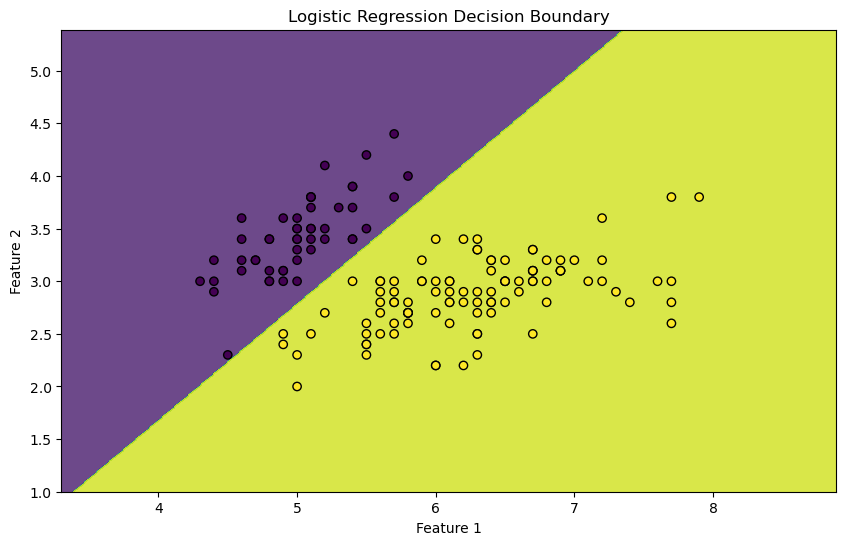

In [75]:
# 5. 可视化决策边界
plt.figure(figsize=(10, 6))

x_min , x_max = X[: , 0].min() - 1 , X[: , 0].max() + 1
y_min , y_max = X[: , 1].min() - 1 , X[: , 1].max() + 1

xx , yy = np.meshgrid(np.arange(x_min , x_max , step=0.01) , np.arange(y_min , y_max , step=0.01))      # meshgrid 生成网格点
print(xx)
print(xx.shape)
print("\n")
print(xx.ravel())
print(xx.ravel().shape)
Z = model.predict(np.c_[xx.ravel() , yy.ravel()])           # 对网格上的每个点进行预测 , np.c_ 合并 xx 和 yy 的 ravel() 方法，将它们转换为一维数组，用于模型预测
Z = Z.reshape(xx.shape)

plt.contourf(xx , yy , Z , alpha=0.8)
plt.scatter(X[: , 0] , X[: , 1] , c=y ,edgecolors='k', marker='o')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Logistic Regression Decision Boundary')
plt.show()